### Task 1: Data Scraping

The data was scraped using the Scrapy framework.

The spider:
- Followed pagination for the first 5 catalog pages.
- Visited each book's detail page.
- Extracted:
  - Title
  - Category
  - Price
  - Rating
  - Availability
  - Product Description
  - UPC
  - Number of Reviews
  - Product URL

The scraped data was exported as `books.csv`.

In [38]:
import pandas as pd

df = pd.read_csv("books.csv")
df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [39]:
df.shape

(100, 9)

In [40]:
#Report the total number of scraped records, missing values, and duplicate UPC values.

print(f"Total Records: {len(df)}")

print("\nMissing Values")

print(df.isnull().sum())

duplicates = df["UPC"].duplicated().sum()

print(f"\nDuplicate UPC Values: {duplicates}")

Total Records: 100

Missing Values
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

Duplicate UPC Values: 0


### Task 2 - Data Preprocessing
- Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.
- Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.
- Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                100 non-null    object
 1   category             100 non-null    object
 2   price                100 non-null    object
 3   rating               100 non-null    object
 4   availability         100 non-null    object
 5   product_description  100 non-null    object
 6   UPC                  100 non-null    object
 7   number_of_reviews    100 non-null    int64 
 8   product_url          100 non-null    object
dtypes: int64(1), object(8)
memory usage: 7.2+ KB


#### Remove leading/trailing spaces from all string columns

In [42]:

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

#### Replace multiple spaces with single space

In [43]:

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

#### Remove Duplicate Books by UPC

In [44]:
print("Duplicates before:", df.duplicated(subset="UPC").sum())

df = df.drop_duplicates(subset="UPC")

print("Duplicates after:", df.duplicated(subset="UPC").sum())

Duplicates before: 0
Duplicates after: 0


#### Replace missing descriptions with "No Description Available"

In [45]:

df["product_description"] = df["product_description"].fillna("No Description Available")
df["product_description"].isnull().sum()

np.int64(0)

#### Convert price to numeric

In [46]:
df["price"] = (df["price"].str.replace("£", "", regex=False).astype(float)
)

df["price"].head()

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: price, dtype: float64

#### Convert rating to numbers

In [47]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

df["rating"].head()

0    2
1    2
2    1
3    1
4    3
Name: rating, dtype: int64

#### Extract available stock count

In [48]:
df["stock_count"] = (
    df["availability"]
    .str.extract(r"(\d+)")
    .fillna(0)
    .astype(int)
)

df[["availability", "stock_count"]].head()

,availability,stock_count
0,In stock (19 available),19
1,In stock (19 available),19
2,In stock (19 available),19
3,In stock (19 available),19
4,In stock (19 available),19


#### Feature 1 : Affordability score

In [49]:
df["affordability_score"] = (
    100 - (df["price"] / df["price"].max()) * 100
).round(2)

#### Feature 2 : Value Score

In [50]:
df["value_score"] = (
    df["rating"] / df["price"]
).round(3)

#### Feature 3 : Recommended

In [51]:
import numpy as np

df["recommended"] = np.where(
    (df["rating"] >= 4) &
    (df["price"] <= 40),
    "Yes",
    "No"
)

In [52]:
df.to_csv("books_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Task 3 - Visualization and Analysis
- Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.
- Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.
- Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
plt.style.use("ggplot")

In [54]:
df = pd.read_csv("books_cleaned.csv")

df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url,stock_count,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,22.27,0.044,No
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,11.67,0.039,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,35.31,0.027,No
3,Olio,Poetry,23.88,1,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,58.91,0.042,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,1.48,0.052,No


In [55]:
df['category'].unique()

array(['Travel', 'Politics', 'Science Fiction', 'Poetry', 'Music',
       'Sequential Art', 'Young Adult', 'Default', 'Business', 'History',
       'Thriller', 'Mystery', 'Philosophy', 'Childrens', 'Nonfiction',
       'Spirituality', 'Art', 'Romance', 'Food and Drink',
       'Add a comment', 'Fiction', 'Fantasy', 'Contemporary', 'New Adult',
       'Horror', 'Health', 'Self Help', 'Science', 'Historical Fiction'],
      dtype=object)

#### Plot 1: Price Distribution

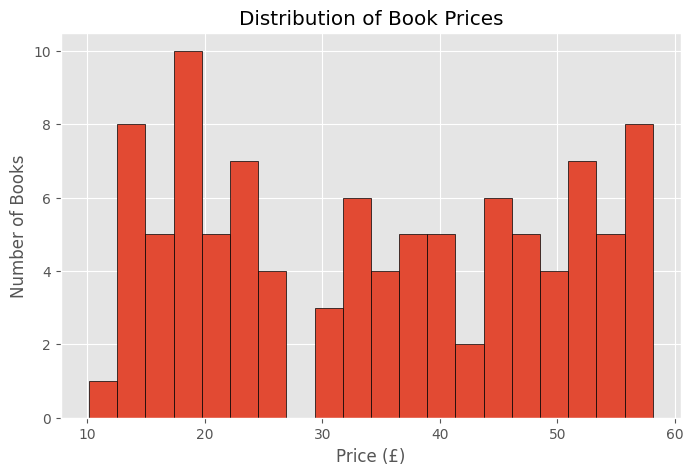

In [56]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

#### Plot 2: Rating Distribution

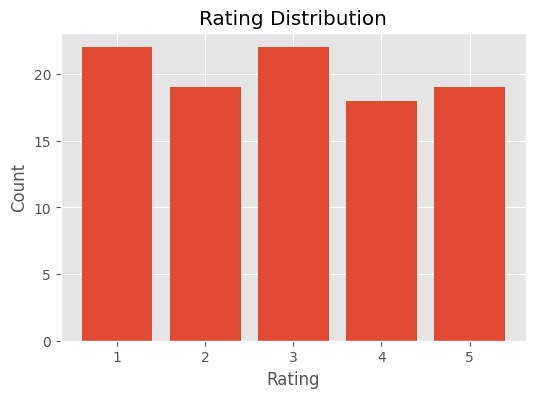

In [57]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

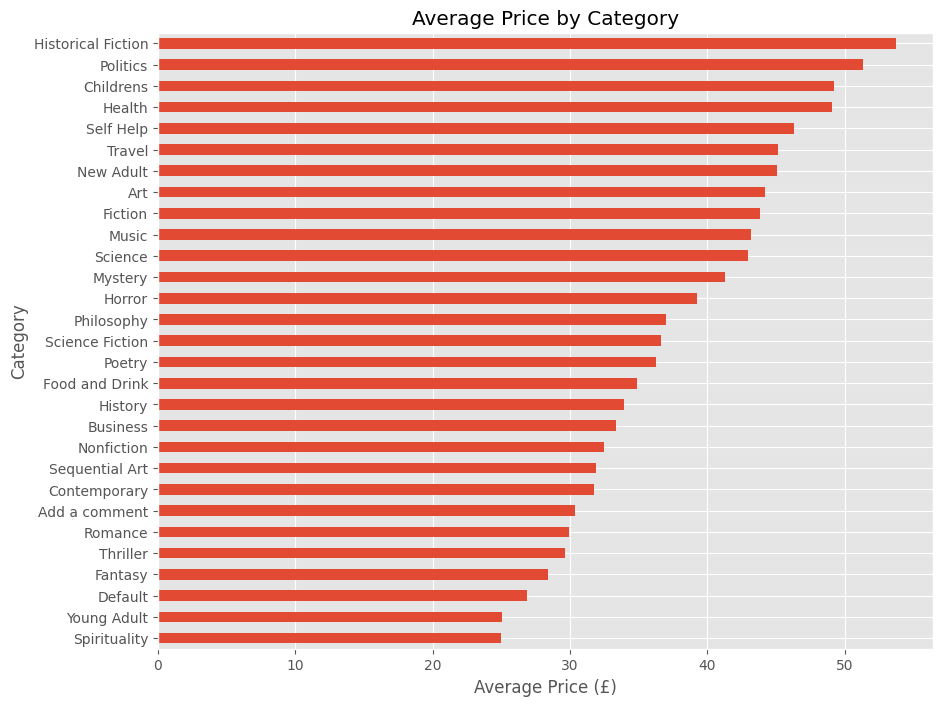

In [58]:
avg_price = (
    df.groupby("category")["price"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,8))

avg_price.plot(kind="barh")

plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.title("Average Price by Category")

plt.show()

#### Plot 4 : Price vs Ratings

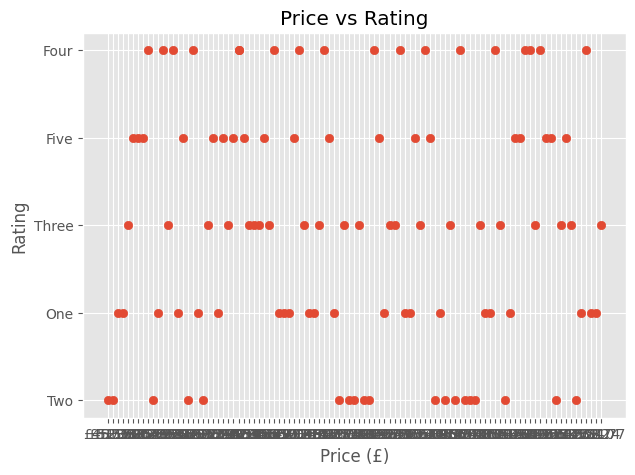

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df["price"], df["rating"])

plt.xlabel("Price (£)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

#### Plot 4 : Category vs Stock

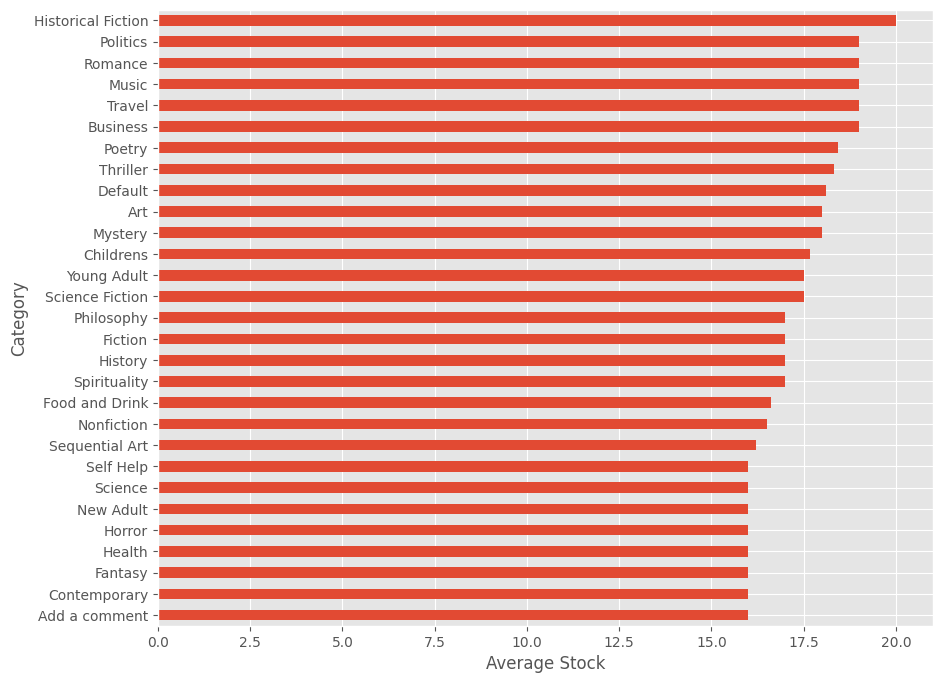

In [59]:
stock = (
    df.groupby("category")["stock_count"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,8))

stock.plot(kind="barh")

plt.xlabel("Average Stock")
plt.ylabel("Category")

plt.show()

#### Wordcloud

In [60]:
# Combine all descriptions into one string.
text = " ".join(df["product_description"].astype(str))

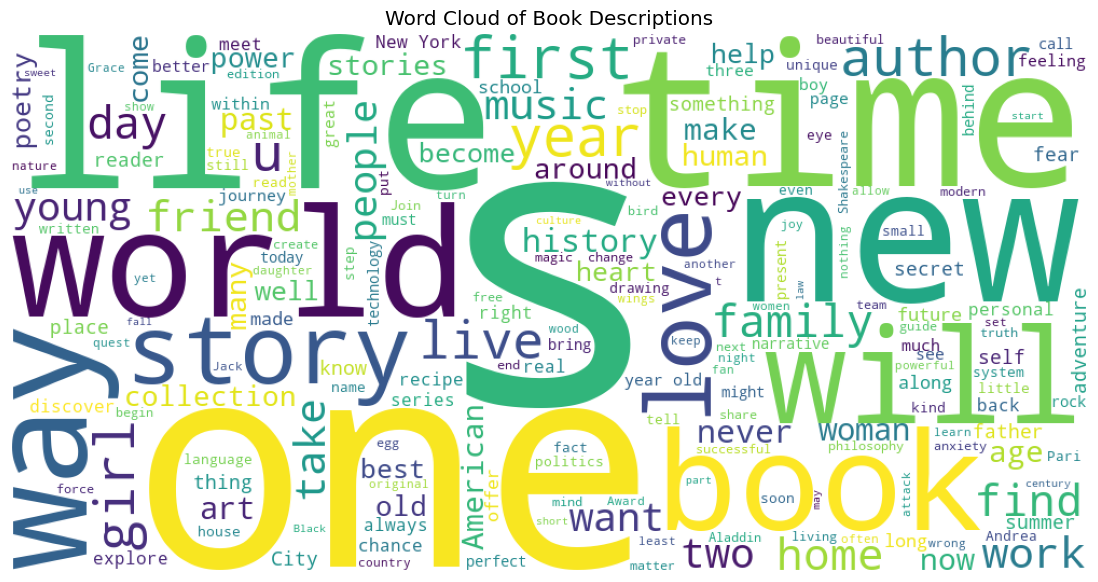

In [61]:
# Generate the word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Book Descriptions")

plt.show()

#### Category Patterns

In [63]:
category_summary = (
    df.groupby("category")
      .agg({
          "price":"mean",
          "rating":"mean",
          "stock_count":"mean"
      })
)

category_summary

,price,rating,stock_count
category,,,
Add a comment,30.342000,2.600000,16.000000
Art,44.180000,4.000000,18.000000
Business,33.340000,4.000000,19.000000
Childrens,49.220000,1.666667,17.666667
Contemporary,31.770000,1.000000,16.000000
Default,26.847778,3.000000,18.111111
Fantasy,28.385000,3.250000,16.000000
Fiction,43.872000,3.800000,17.000000
Food and Drink,34.886000,2.200000,16.600000


#### Highly rated books

In [64]:
highly_rated = df[df["rating"] == 5]

highly_rated[
    ["title","category","price","rating"]
].head(10)

,title,category,price,rating
5,Rip it Up and Start Again,Music,35.02,5
6,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,52.29,5
7,Set Me Free,Young Adult,17.46,5
15,Sapiens: A Brief History of Humankind,History,54.23,5
21,Sophie's World,Philosophy,15.94,5
23,The Elephant Tree,Thriller,23.82,5
25,The Four Agreements: A Practical Guide to Pers...,Spirituality,17.66,5
27,Worlds Elsewhere: Journeys Around Shakespeare’...,Nonfiction,40.30,5
31,Black Dust,Romance,34.53,5
37,Thirst,Fiction,17.27,5


#### Stock Pattern

In [65]:
df.nlargest(
    10,
    "stock_count"
)[
    ["title","stock_count"]
]

,title,stock_count
99,A Light in the Attic,22
15,Sapiens: A Brief History of Humankind,20
96,Sharp Objects,20
97,Soumission,20
98,Tipping the Velvet,20
0,It's Only the Himalayas,19
1,Libertarianism for Beginners,19
2,Mesaerion: The Best Science Fiction Stories 18...,19
3,Olio,19
4,Our Band Could Be Your Life: Scenes from the A...,19


#### Unusual values

In [66]:
df.nlargest(
    10,
    "price"
)[
    ["title","price"]
]

,title,price
59,The Death of Humanity: and the Case for Life,58.11
91,Slow States of Collapse: Poems,57.31
4,Our Band Could Be Your Life: Scenes from the A...,57.25
33,The Past Never Ends,56.50
34,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41
72,Masks and Shadows,56.40
35,The Secret of Dreadwillow Carse,56.13
60,The Electric Pencil: Drawings from Inside Stat...,56.06
30,Birdsong: A Story in Pictures,54.64
15,Sapiens: A Brief History of Humankind,54.23


In [67]:
df.nsmallest(
    10,
    "price"
)[
    ["title","price"]
]

,title,price
79,Patience,10.16
95,In Her Wake,12.84
82,Princess Between Worlds (Wide-Awake Princess #5),13.34
83,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61
9,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99
71,Mama Tried: Traditional Italian Cooking for th...,14.02
75,On a Midnight Clear,14.07
44,Untitled Collection: Sabbath Poems 2014,14.27
74,Obsidian (Lux #1),14.86
78,"Outcast, Vol. 1: A Darkness Surrounds Him (Out...",15.44


## Analysis

- Most books are priced between £20 and £40.
- Ratings of 3 and 4 are the most common.
- Some categories have consistently higher average prices than others.
- There is little evidence of a strong relationship between price and rating.
- Books with the highest stock counts are concentrated in a few categories.
- The word cloud shows frequently occurring words from book descriptions, highlighting common themes.
- No duplicate UPC values were found after preprocessing.
- Missing descriptions were handled during preprocessing.